### Config

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import torch, os

# Adjust to point to the actual root of your project
PROJECT_ROOT = Path.cwd().parent  # or Path("/absolute/path/to/your/project")
sys.path.insert(0, str(PROJECT_ROOT))

### Time Serries Loading

In [2]:
from src.activation_recorder import MultiPromptActivations

save_dir = "../data/activations"
dir_path = os.path.join(save_dir, "multi_prompt_activations.pkl")
activations = MultiPromptActivations.load(dir_path)

/home/p84400019/miniconda3/envs/int/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MultiPromptActivations successfully loaded from '../data/activations/multi_prompt_activations.pkl'.


Prompt 0 has 100 generated tokens: ['\n', '1', ' Answer', ' |', ' Add', ' Yours', '\n', 'The', ' most', ' obvious', ' adaptation', ' that', ' humans', ' would', ' develop', ' would', ' be', ' g', 'ills', '.', ' This', ' would', ' allow', ' them', ' to', ' breathe', ' underwater', '.', ' This', ' would', ' be', ' a', ' huge', ' adaptation', '.', ' It', ' would', ' allow', ' humans', ' to', ' live', ' in', ' the', ' ocean', ' and', ' not', ' have', ' to', ' come', ' to', ' the', ' surface', ' to', ' breathe', '.', ' This', ' would', ' allow', ' humans', ' to', ' live', ' in', ' the', ' ocean', ' and', ' not', ' have', ' to', ' come', ' to', ' the', ' surface', ' to', ' breathe', '.', '\n', 'Hum', 'ans', ' would', ' also', ' have', ' to', ' develop', ' a', ' way', ' to', ' survive', ' in', ' the', ' ocean', '.', ' They', ' would', ' have', ' to', ' be', ' able', ' to', ' withstand', ' the']


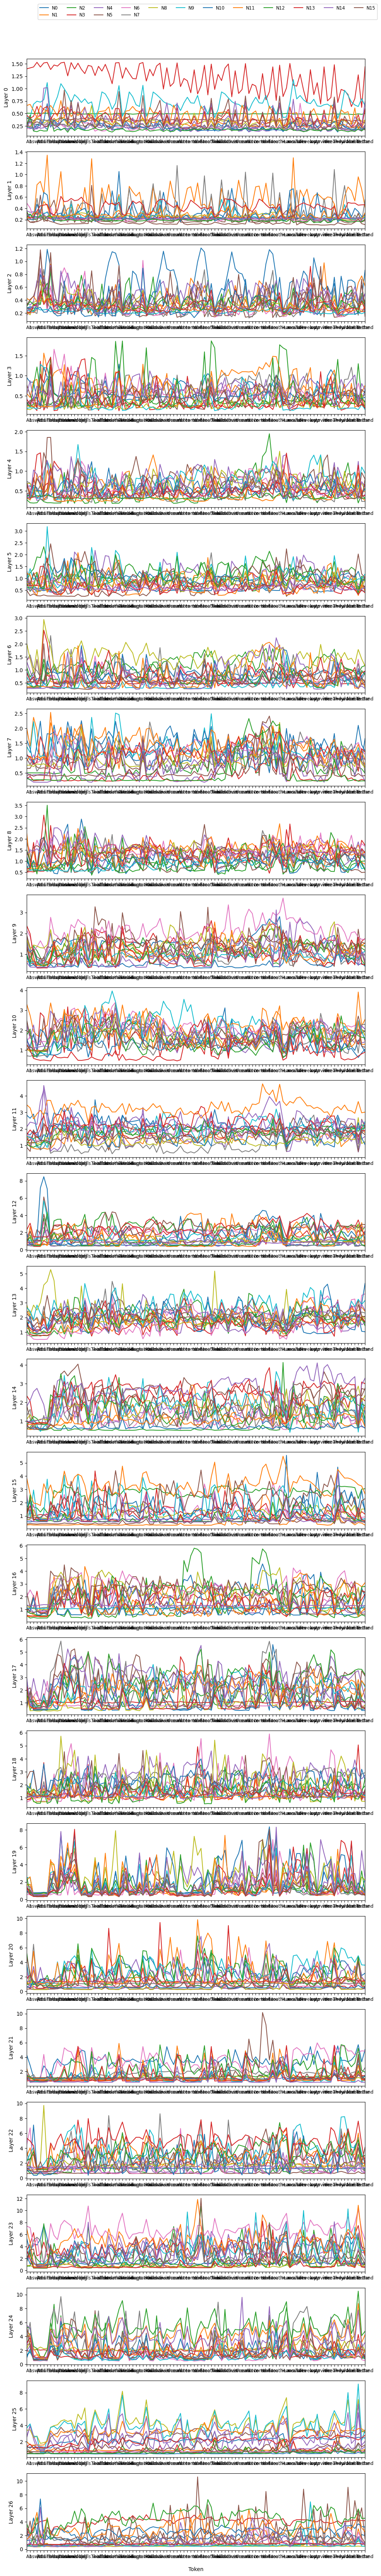

In [3]:
from src.time_series_activations import MultiPromptTimeSeries

time_series = MultiPromptTimeSeries.from_activations(
    activations, 
    # node_type="moe",  node_activation="expert_output",
    node_type="attention", node_activation="attention_outputs",
    projection_method="norm", 
    exclude_shared_expert_moe=True, 
)
time_series.plot(token_x=True, ticks_all_layers=True)

### PhyID Decomposition

In [4]:
from src.phyid_decomposition import MultiPromptPhyID, PromptPhyID, PhyIDTimeSeries

phyid_comp = MultiPromptPhyID.from_time_series(time_series) 
phyid_comp.save(dir_path="../data/phyid_decompotsition")

Processing prompt 1/1 with 100 generated tokens.
[ETA] 1/186192 done | avg=0.033s | ETA ≈ 1:41:56
[ETA] 10/186192 done | avg=0.007s | ETA ≈ 0:21:21
[ETA] 100/186192 done | avg=0.003s | ETA ≈ 0:08:43


[ETA] 1000/186192 done | avg=0.002s | ETA ≈ 0:07:30
[ETA] 10000/186192 done | avg=0.002s | ETA ≈ 0:07:07
[ETA] 100000/186192 done | avg=0.002s | ETA ≈ 0:03:23
[ETA] 186192/186192 done | avg=0.002s | ETA ≈ 0:00:00
MultiPromptPhyID successfully saved to '../data/phyid_decompotsition/multi_prompt_phyid.pkl'.


In [ ]:
phyid = MultiPromptPhyID.load(file_path="../data/phyid_decompotsition/multi_prompt_phyid.pkl")
phyid = phyid.get_prompt(prompt_index=0)  # Get the first prompt's phyid
phyid.build_data_array()

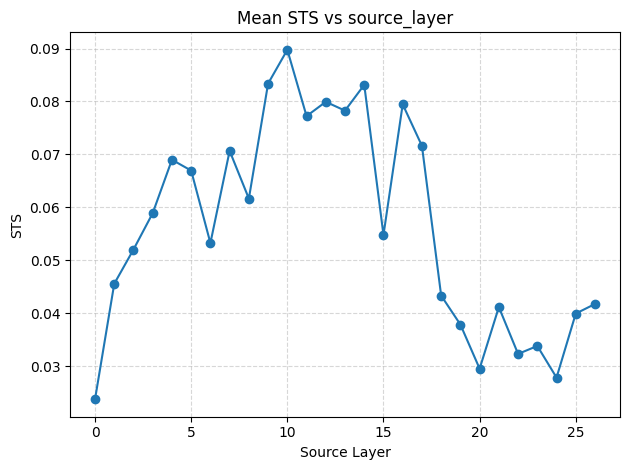

In [18]:
# phyid.node_heatmap(atom='sts')
phyid.plot_mean_along('sts', varying_dim='source_layer')